# Support Ticket Topic Classification Using Machine Learning
### Future Interns — Machine Learning Task 2 (2026)

**Author:** Arnaud Bozahbe  
**Notebook objective:** Build a clean and practical text classification pipeline using the improved support ticket dataset.

This notebook uses `all_tickets_processed_improved_v3.csv.zip` with two main columns: `Document` and `Topic_group`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 120)

## 1. Load and clean the dataset

In [4]:
zip_path = '/home/guest/Downloads/all_tickets_processed_improved_v3.csv.zip'
csv_name = 'all_tickets_processed_improved_v3.csv'

with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_name) as f:
        df = pd.read_csv(f)

print('Original shape:', df.shape)
df = df.dropna(subset=['Document', 'Topic_group']).copy()
df['Document'] = df['Document'].astype(str).str.strip().str.lower()
df['Topic_group'] = df['Topic_group'].astype(str).str.strip()
df = df[(df['Document'] != '') & (df['Topic_group'] != '')].reset_index(drop=True)
print('Cleaned shape :', df.shape)
print('Classes       :', df['Topic_group'].nunique())
df.head()

Original shape: (47837, 2)
Cleaned shape : (47837, 2)
Classes       : 8


,Document,Topic_group
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware
1,work experience user work experience user hi work experience student coming next his name much appreciate him durati...,Access
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days im...,Access
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Miscellaneous


## 2. Exploratory analysis

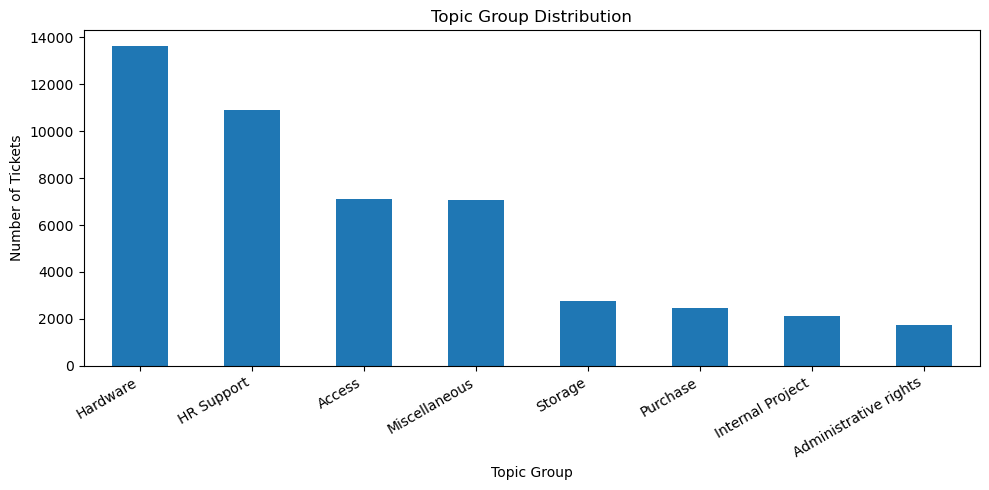

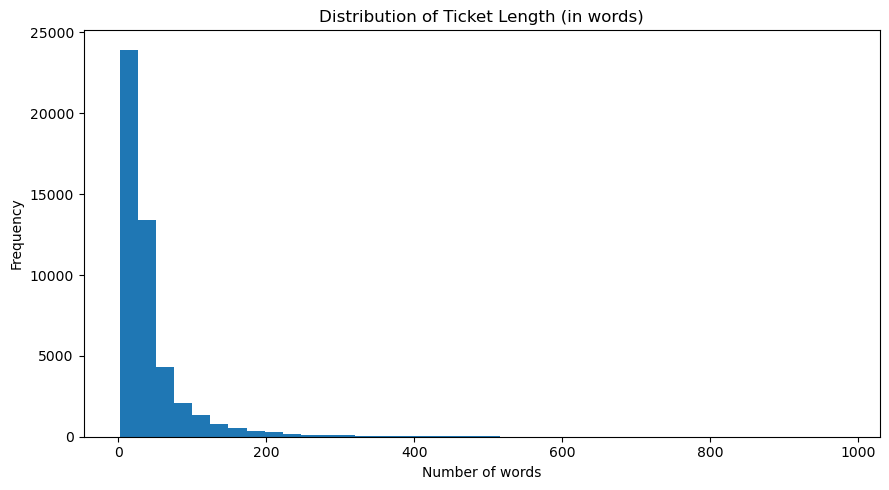

Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64

In [5]:
class_counts = df['Topic_group'].value_counts()
plt.figure(figsize=(10,5))
class_counts.plot(kind='bar')
plt.title('Topic Group Distribution')
plt.xlabel('Topic Group')
plt.ylabel('Number of Tickets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df['text_length_words'] = df['Document'].str.split().apply(len)
plt.figure(figsize=(9,5))
plt.hist(df['text_length_words'], bins=40)
plt.title('Distribution of Ticket Length (in words)')
plt.xlabel('Number of words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

class_counts

## 3. Train / test split

In [6]:
X = df['Document']
y = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

baseline_accuracy = y.value_counts(normalize=True).max()
print(f'Train size: {len(X_train):,}')
print(f'Test size : {len(X_test):,}')
print(f'Baseline  : {baseline_accuracy:.4f}')

Train size: 38,269
Test size : 9,568
Baseline  : 0.2847


## 4. Model comparison

In [7]:
models = {
    'MultinomialNB': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=12000, ngram_range=(1,2), min_df=3, sublinear_tf=False)),
        ('clf', MultinomialNB(alpha=0.1))
    ]),
    'SGDClassifier': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=12000, ngram_range=(1,2), min_df=3, sublinear_tf=True)),
        ('clf', SGDClassifier(loss='hinge', random_state=RANDOM_STATE))
    ]),
    'LinearSVC': Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=12000, ngram_range=(1,2), min_df=3, sublinear_tf=True)),
        ('clf', LinearSVC(random_state=RANDOM_STATE, max_iter=3000))
    ])
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Weighted F1': f1_score(y_test, preds, average='weighted')
    })

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Weighted F1
0,SGDClassifier,0.857860,0.857776
1,LinearSVC,0.852634,0.852726
2,MultinomialNB,0.794837,0.794461


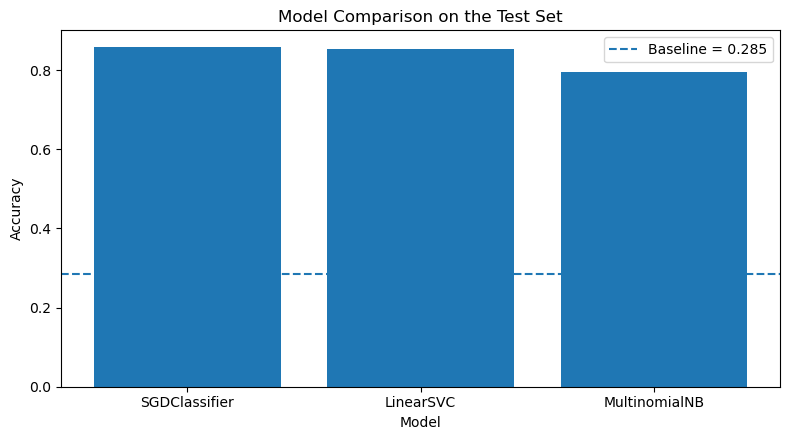

In [8]:
plt.figure(figsize=(8,4.5))
plt.bar(results_df['Model'], results_df['Accuracy'])
plt.axhline(baseline_accuracy, linestyle='--', label=f'Baseline = {baseline_accuracy:.3f}')
plt.title('Model Comparison on the Test Set')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Final model and evaluation

In [9]:
final_model = models['LinearSVC']
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred, average='weighted')

print('Final Model: LinearSVC')
print(f'Accuracy    : {final_accuracy:.4f}')
print(f'Weighted F1 : {final_f1:.4f}')
print(f'Baseline    : {baseline_accuracy:.4f}')
print()
print(classification_report(y_test, y_pred))

Final Model: LinearSVC
Accuracy    : 0.8526
Weighted F1 : 0.8527
Baseline    : 0.2847

                       precision    recall  f1-score   support

               Access       0.89      0.90      0.90      1425
Administrative rights       0.85      0.71      0.78       352
           HR Support       0.87      0.86      0.86      2183
             Hardware       0.82      0.86      0.84      2724
     Internal Project       0.88      0.85      0.87       424
        Miscellaneous       0.81      0.81      0.81      1412
             Purchase       0.94      0.88      0.91       493
              Storage       0.92      0.86      0.89       555

             accuracy                           0.85      9568
            macro avg       0.87      0.84      0.86      9568
         weighted avg       0.85      0.85      0.85      9568



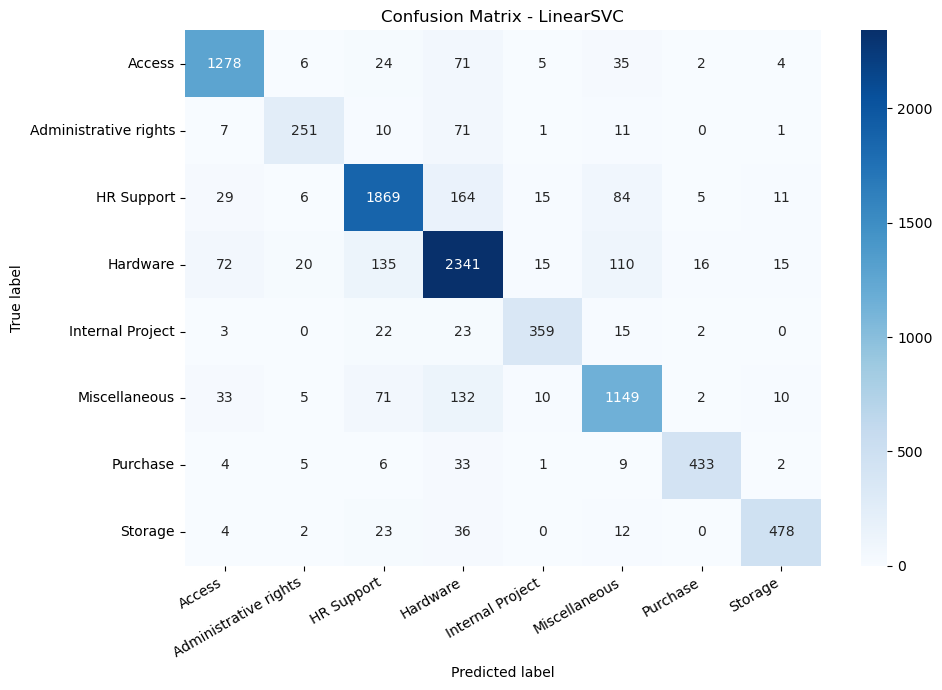

In [10]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - LinearSVC')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Cross-validation and demo

In [11]:
cv_model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=12000, ngram_range=(1,2), min_df=3, sublinear_tf=True)),
    ('clf', LinearSVC(random_state=RANDOM_STATE, max_iter=3000))
])

cv_scores = cross_val_score(cv_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)
print('5-Fold Cross-Validation Accuracy Scores:')
print(np.round(cv_scores, 4))
print(f'Mean accuracy: {cv_scores.mean():.4f}')
print(f'Std dev      : {cv_scores.std():.4f}')

demo_tickets = [
    'please reset my password because i can no longer access my external account',
    'i need a new laptop charger and a replacement docking station for my office setup',
    'the shared drive is full and we cannot upload the latest project files',
    'i want to buy two monitors and one keyboard for the new employee',
    'we need help with onboarding documents and leave policy clarification'
]

demo_predictions = final_model.predict(demo_tickets)
for text, pred in zip(demo_tickets, demo_predictions):
    print()
    print('Ticket:', text)
    print('Predicted topic:', pred)

/home/guest/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/guest/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/guest/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/guest/anaconda3/lib/python3.12/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/home/guest/anaconda3/lib/py

5-Fold Cross-Validation Accuracy Scores:
[0.8318 0.8005 0.7847 0.8073 0.751 ]
Mean accuracy: 0.7951
Std dev      : 0.0268

Ticket: please reset my password because i can no longer access my external account
Predicted topic: Access

Ticket: i need a new laptop charger and a replacement docking station for my office setup
Predicted topic: Hardware

Ticket: the shared drive is full and we cannot upload the latest project files
Predicted topic: Storage

Ticket: i want to buy two monitors and one keyboard for the new employee
Predicted topic: Hardware

Ticket: we need help with onboarding documents and leave policy clarification
Predicted topic: Hardware


## 7. Conclusion

This notebook provides a cleaner and more relevant practical part for the internship task. It uses the improved dataset, applies TF-IDF text features, compares several models, keeps LinearSVC as the final classifier, and evaluates the system with accuracy, weighted F1-score, a confusion matrix, cross-validation, and live prediction examples.